# APE 005 - Distribuciones Discretas Notables

## Modelado y Simulación de Procesos de Bernoulli y Eventos Raros

En esta práctica se aplicarán distribuciones discretas utilizando Python y el dataset ambiental 2025.

Se trabajará con:

- Distribución Binomial.
- Distribución de Poisson.
- PMF y CDF.
- Histogramas.
- Comparación entre datos empíricos y modelos teóricos.
## 1. Introducción
En esta práctica se explora la naturaleza del azar mediante la modelación computacional. Utilizaremos el ecosistema de ciencia de datos de Python para diferenciar empíricamente entre variables discretas (lanzamiento de dados) y continuas (tiempos de respuesta de servidores).

## 2. Objetivos de Aprendizaje
*	Calcular teórica y computacionalmente la esperanza matemática y la varianza  de variables aleatorias discretas y continuas utilizando la librería scipy.stats en Python.
* Aplicar el análisis de tendencia central y dispersión sobre el conjunto de datos (dataset) regional seleccionado para el Proyecto Integrador, facilitando el hito de la semana.
* Validar los conceptos adquiridos en la clase invertida de la semana 4 (variables aleatorias) integrándolos en la resolución de problemas (ABP).


## 1. Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom
from scipy.stats import poisson

## 2. Subir el dataset en Google Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Dataset_hogares_ambiental_2025.xlsx to Dataset_hogares_ambiental_2025 (1).xlsx


## 3. Cargar el dataset

In [ ]:
archivo = "Dataset_hogares_ambiental_2025.xlsx"

df_original = pd.read_excel(archivo)

df_original.head()

,area,ciudad,conglomerado,panelm,vivienda,hogar,s101p11,s101p12a,s101p12b,s101p12c,...,s91p121,s91p122,s91p123,s91p124,s91p125,s91p126,s91p131,s91p132,s91p133,fexp
0,1,10150,3101,71,4,1,1,1,1,1,...,5,5,5,5,5,1,1,5,1,130.642361
1,1,10150,3801,74,3,1,1,1,1,1,...,5,3,3,5,5,1,3,2,4,73.698631
2,1,10150,3801,74,4,1,1,1,1,2,...,5,5,5,4,4,1,3,3,5,73.698631
3,1,10150,3801,74,5,1,1,1,1,1,...,5,5,3,5,5,1,2,3,5,73.698631
4,1,10150,3801,74,7,1,1,1,1,2,...,5,5,5,5,5,1,3,5,4,73.698631


# Tarea 1 - Distribución Binomial

La distribución Binomial modela el número de éxitos $^x$ en $^n$ ensayos
independientes de Bernoulli, con probabilidad de éxito $^p$. Su PMF está dada por:

<br>

$P(X=x)$ = $(n/x) p^x (1-p)^{n-x}$

<br>

Abra un nuevo Jupyter Notebook llamado APE_006_Distribuciones.ipynb.
Suponga un escenario de control de calidad de software donde un lote de 20
microservicios tiene una probabilidad del 15% de fallar bajo estrés. Escriba y
ejecute el siguiente código:

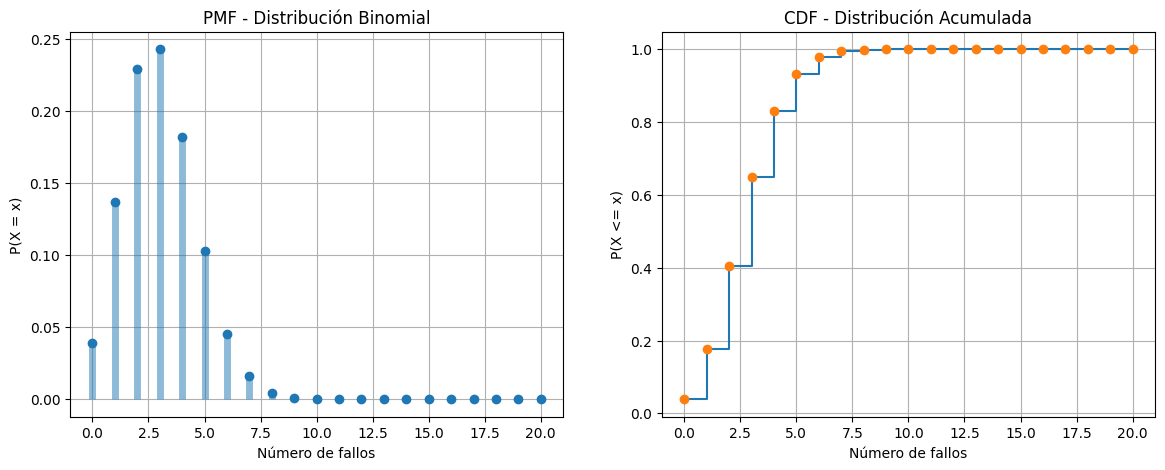

La probabilidad de encontrar 3 o menos artículos defectuosos es: 0.6477


In [ ]:
# Parámetros Binomiales

n_ensayos = 20
p_falla = 0.15

# Valores posibles

x = np.arange(0, n_ensayos + 1)

# PMF y CDF

pmf_binomial = binom.pmf(x, n_ensayos, p_falla)

cdf_binomial = binom.cdf(x, n_ensayos, p_falla)

# Gráficos

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# PMF

ax[0].vlines(x, 0, pmf_binomial, lw=5, alpha=0.5)

ax[0].plot(x, pmf_binomial, 'o')

ax[0].set_title("PMF - Distribución Binomial")

ax[0].set_xlabel("Número de fallos")

ax[0].set_ylabel("P(X = x)")

ax[0].grid(True)

# CDF

ax[1].step(x, cdf_binomial, where='post')

ax[1].plot(x, cdf_binomial, 'o')

ax[1].set_title("CDF - Distribución Acumulada")

ax[1].set_xlabel("Número de fallos")

ax[1].set_ylabel("P(X <= x)")

ax[1].grid(True)

plt.show()

# Cálculo específico solicitado: P(X <= 3)
prob_acumulada = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de encontrar 3 o menos artículos defectuosos es: {prob_acumulada:.4f}")

## Probabilidad acumulada

Se calcula la probabilidad de tener 3 fallos o menos.

In [ ]:
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)

print("Probabilidad de tener 3 fallos o menos:")

print(prob_max_3)

Probabilidad de tener 3 fallos o menos:
0.6477251741567033


# Tarea 2 - Distribución de Poisson

Simulación de la Distribución de Poisson basándote en un escenario de "eventos raros", específicamente modelando el promedio de $\lambda=4.5$ peticiones de acceso erróneas por minuto que reciben los servidores de la universidad. Utilizando la librería scipy.stats.poisson, debes escribir un script en Python que genere un gráfico de la Función de Masa de Probabilidad (PMF) evaluando el rango de $x=0$ hasta $x=15$, y finalmente calcular mediante código la probabilidad exacta de que ocurran exactamente 6 peticiones erróneas en un minuto ($P(X=6)$).

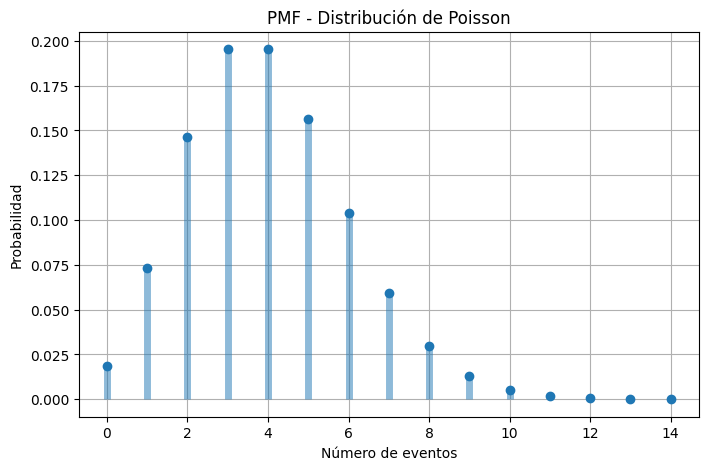

In [ ]:
# Parámetro lambda

lambda_poisson = 4

# Valores posibles

x_poisson = np.arange(0, 15)

# PMF de Poisson

pmf_poisson = poisson.pmf(x_poisson, lambda_poisson)

# Gráfico

plt.figure(figsize=(8,5))

plt.vlines(x_poisson, 0, pmf_poisson, lw=5, alpha=0.5)

plt.plot(x_poisson, pmf_poisson, 'o')

plt.title("PMF - Distribución de Poisson")

plt.xlabel("Número de eventos")

plt.ylabel("Probabilidad")

plt.grid(True)

plt.show()

## Probabilidad exacta

Se calcula la probabilidad de recibir exactamente 6 peticiones erróneas.

In [ ]:
prob_6 = poisson.pmf(6, lambda_poisson)

print("Probabilidad de exactamente 6 eventos:")

print(prob_6)

Probabilidad de exactamente 6 eventos:
0.10419563456702102


# Tarea 3 - Aplicación al Dataset Ambiental

Cargue su dataset regional en pandas.
Identifique una variable discreta que represente un "conteo" (ej. número de
accidentes semanales en Loja, número de transacciones diarias, cantidad de
clientes por hora).
Calcule la media muestral ( $\bar{x}$ ) de esa variable y asuma que es el parámetro $\lambda$
para un modelo de Poisson teórico.
Genere un gráfico superponiendo el histograma de densidad de su variable
empírica contra la línea de la PMF teórica de Poisson generada en scipy. Discuta
visualmente si los datos reales siguen esta distribución.


En este caso se utilizará la variable:

- hogar

Media muestral (λ): 1.00


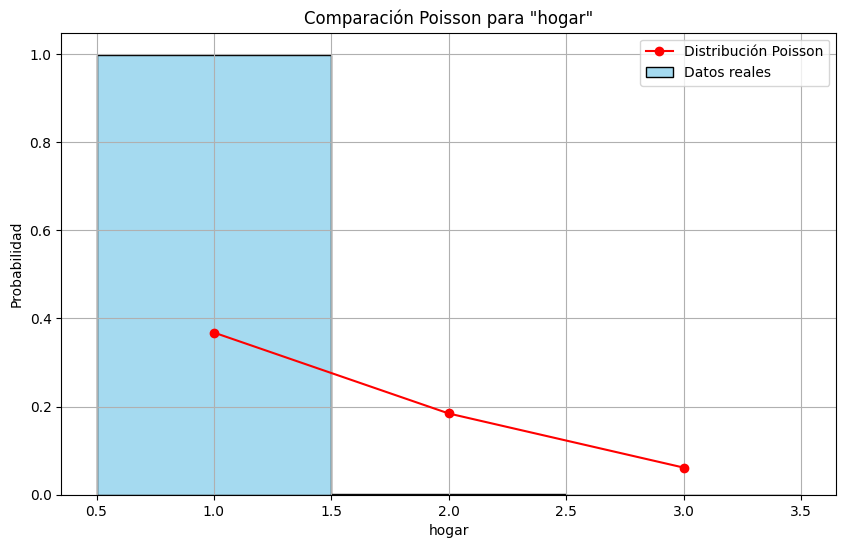


Interpretación:
Se comparó la distribución real de la variable 'hogar' con una distribución teórica de Poisson.
El gráfico permite observar visualmente si los datos siguen un comportamiento similar al modelo probabilístico de Poisson.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

# Cargar dataset
df = pd.read_excel("Dataset_hogares_ambiental_2025 (1).xlsx")

# Mostrar primeras filas
df.head()

# Variable discreta seleccionada
count_variable = "hogar"

# Convertir a numérico
df[count_variable] = pd.to_numeric(df[count_variable], errors='coerce')

# Eliminar valores nulos
df_cleaned = df.dropna(subset=[count_variable])

# Convertir a entero
df_cleaned[count_variable] = df_cleaned[count_variable].astype(int)

# Calcular lambda (media)
lambda_param = df_cleaned[count_variable].mean()

print(f"Media muestral (λ): {lambda_param:.2f}")

# Crear gráfico
plt.figure(figsize=(10,6))

# Histograma empírico
sns.histplot(
    df_cleaned[count_variable],
    stat='density',
    discrete=True,
    color='skyblue',
    label='Datos reales'
)

# PMF teórica Poisson
k_values = np.arange(
    df_cleaned[count_variable].min(),
    df_cleaned[count_variable].max() + 1
)

pmf_poisson = poisson.pmf(k_values, mu=lambda_param)

# Curva Poisson
plt.plot(
    k_values,
    pmf_poisson,
    'ro-',
    label='Distribución Poisson'
)

# Títulos
plt.title(f'Comparación Poisson para "{count_variable}"')
plt.xlabel(count_variable)
plt.ylabel('Probabilidad')

plt.legend()
plt.grid(True)

plt.show()

# Interpretación
print("\nInterpretación:")
print("Se comparó la distribución real de la variable 'hogar' con una distribución teórica de Poisson.")
print("El gráfico permite observar visualmente si los datos siguen un comportamiento similar al modelo probabilístico de Poisson.")

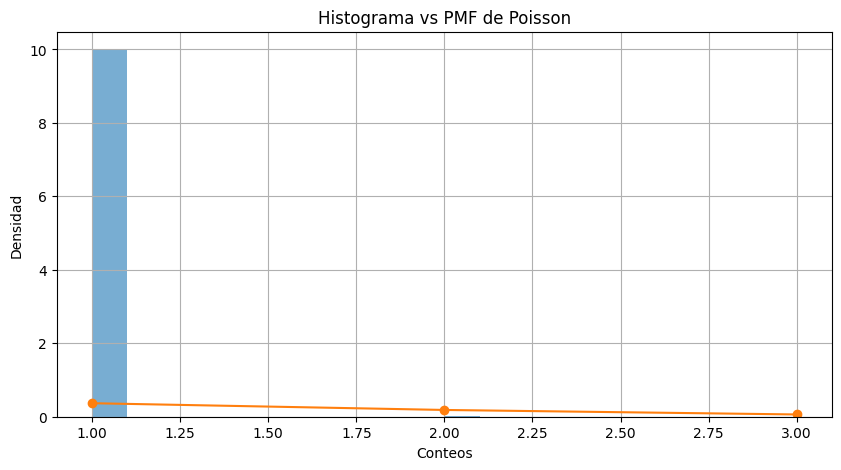

In [ ]:
# Histograma empírico
plt.figure(figsize=(10,5))

# Usar el rango de tu variable 'hogar'
conteos = np.arange(
    df_cleaned[count_variable].min(),
    df_cleaned[count_variable].max() + 1
)

# Histograma
plt.hist(
    df_cleaned[count_variable], # Variable correcta
    bins=20,
    density=True,
    alpha=0.6
)

# PMF Poisson usando lambda_param
pmf_teorica = poisson.pmf(conteos, lambda_param) # Variable correcta

plt.plot(
    conteos,
    pmf_teorica,
    'o-'
)

plt.title("Histograma vs PMF de Poisson")
plt.xlabel("Conteos")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

## Análisis

Si el histograma empírico tiene una forma similar a la PMF de Poisson, entonces la variable puede aproximarse a una distribución de Poisson.

Si existen diferencias grandes, entonces la variable no sigue correctamente este modelo probabilístico.

---
## **Tarea 4: ABI - Aproximación Binomial a Poisson**

##**ABI - Aproximación Binomial a Poisson**
Investigue bajo qué condiciones matemáticas una distribución Binomial se aproxima a una de Poisson. Redacte un bloque Markdown explicando la relación **λ = n * p** cuando **n -> ∞** y **p -> 0**   
### **Aproximación Binomial a Poisson**

Una distribución Binomial puede aproximarse mediante una distribución de Poisson cuando el número de ensayos \(n\) es muy grande y la probabilidad de éxito \(p\) es muy pequeña.

Matemáticamente:

[n -> ∞] & [p -> 0]

manteniendo constante:


[λ = n * p  ]  

Donde:  


λ -> número de éxitos esperado

Esta aproximación es útil para modelar eventos raros, ya que simplifica cálculos probabilísticos complejos de la distribución Binomial.

En esta práctica se comparará una distribución Binomial con parámetros:

- \(n = 1000\)
- \(p = 0.003\)

con una distribución de Poisson donde:

\[
λ = 1000(0.003)=3
\]

Esperamos que ambas probabilidades sean casi idénticas.  


In [ ]:
from scipy.stats import binom, poisson

# Parámetros
n = 1000
p = 0.003
lam = n * p

# Valor a evaluar
x = 2

# Probabilidad Binomial
prob_binomial = binom.pmf(x, n, p)

# Probabilidad Poisson
prob_poisson = poisson.pmf(x, lam)

# Resultados
print("Distribución Binomial")
print(f"P(X = {x}) = {prob_binomial:.6f}")

print("\nDistribución de Poisson")
print(f"P(X = {x}) = {prob_poisson:.6f}")

# Diferencia
diferencia = abs(prob_binomial - prob_poisson)

print("\nDiferencia absoluta:")
print(f"{diferencia:.10f}")

Distribución Binomial
P(X = 2) = 0.224154

Distribución de Poisson
P(X = 2) = 0.224042

Diferencia absoluta:
0.0001119363


###¿Que representa?  
**Binomial**:  
Calcula la probabilidad de exactamente 2 éxitos en 1000 intentos  

**Poisson:**  
Hace lo mismo, pero, usando aproximación  

**Conclusion:**  
Los resultados obtenidos muestran que la distribución de Poisson aproxima correctamente a la distribución Binomial cuando el número de ensayos es grande y la probabilidad de éxito es pequeña. La diferencia entre ambas probabilidades fue mínima, confirmando la validez teórica de la aproximación.

# Preguntas de Control

## **1. ¿Por qué la CDF discreta tiene forma escalonada?**

Una variable aleatoria discreta solo puede tomar valores específicos y aislados (por ejemplo: 0, 1, 2, 3...). Por esta naturaleza, su gráfica presenta un comportamiento único:

* **Valores específicos:** La probabilidad acumulada no aumenta de manera continua, sino "por saltos" cada vez que aparece un nuevo valor posible en el eje $x$.
* **Intervalos de probabilidad constante:** Entre un valor entero y el siguiente (por ejemplo, entre 1 y 2), la probabilidad no cambia porque no existen valores intermedios posibles. Esto genera las líneas horizontales o "mesetas" de la escalera.
* **Incrementos repentinos:** En el momento exacto en que $x$ alcanza un valor con probabilidad distinta de cero, la función sube verticalmente.

**Explicación Matemática:**
La CDF se define como la suma de las probabilidades de todos los valores menores o iguales a $x$:

$$F(x) = P(X \leq x) = \sum_{x_i \leq x} P(X = x_i)$$



Mientras que en las variables continuas la probabilidad fluye suavemente mediante integrales (creando curvas), en las discretas la función va sumando probabilidades en puntos exactos, lo que genera inevitablemente esos **escalones**.


## **2. ¿Se puede usar Binomial al extraer cartas sin reemplazo?**


**No**, este escenario no puede modelarse mediante una distribución binomial por las siguientes razones:

* **Falta de independencia:** La distribución binomial requiere que los ensayos sean independientes. En una extracción sin reemplazo, el resultado de la primera carta afecta directamente las probabilidades de las siguientes.
* **Probabilidad variable:** Para que sea binomial, la probabilidad de éxito ($p$) debe permanecer constante. Al no devolver las cartas a la baraja:
    * La probabilidad inicial de sacar un as es $P(As) = \frac{4}{52}$.
    * Si la primera carta fue un as, la probabilidad para la segunda extracción cambia a $P(As_{siguiente}) = \frac{3}{51}$.
* **Modelo correcto:** Debido a que existe dependencia estadística y la probabilidad cambia en cada ensayo, el modelo matemático adecuado para este caso es la **distribución hipergeométrica**.

**Conclusión:** Al no existir independencia ni probabilidad constante, no se cumplen los supuestos fundamentales del modelo binomial.


## 3. ¿Qué limitaciones tiene asumir lambda constante?

Decir que la tasa media (λ) permanece constante durante todo el periodo de estudio presenta varias limitaciones. Una de ellas es que, cuando la varianza es alta, la media pierde confiabilidad como representación del comportamiento real de los datos. Además, la presencia de valores atípicos y sesgos puede alterar significativamente la media, haciendo que no refleje adecuadamente la realidad del dataset. También se ignoran los cambios y variaciones que ocurren entre los años 2022 y 2025, especialmente en variables ambientales y sociales.
Respecto a la estacionariedad, no se cumple de manera estricta, ya que los datos muestran variabilidad temporal, fluctuaciones anuales y distribuciones no constantes. El uso de histogramas y medidas de dispersión evidencia que las propiedades estadísticas cambian a lo largo del tiempo, por lo que no es correcto asumir una media fija y estable durante todo el periodo de estudio.



## 4. ¿Cuándo es válida la aproximación Binomial-Poisson?

La aproximación de una distribución Binomial $B(n, p)$ a una de Poisson $P(\lambda)$ es una herramienta fundamental cuando se trabaja con "eventos raros". Para que esta aproximación sea considerada estadísticamente segura y precisa, se deben cumplir las siguientes condiciones:

* **Número de ensayos grande ($n$):** El número de experimentos o ensayos debe ser elevado, generalmente se considera seguro si $n \geq 30$.
* **Probabilidad de éxito pequeña ($p$):** La probabilidad de que ocurra el evento de interés debe ser muy baja, usualmente $p \leq 0.1$.
* **Producto constante ($\lambda$):** El promedio de éxitos esperado, definido como $\lambda = n \cdot p$, debe mantenerse constante y, preferiblemente, ser menor a 10 para minimizar el margen de error.


**Conclusión:**
Cuando estas condiciones se cumplen (como se demostró en la Tarea 4 con $n=100$ y $p=0.04$), la distribución de Poisson simplifica el cálculo de probabilidades complejas sin perder exactitud, ya que ambas funciones de masa de probabilidad convergen en sus resultados.



## 5. ¿La media es igual a la varianza en Poisson?

Al calcular los estadísticos descriptivos correspondientes a la variable prácticas de conservación, se obtuvo una media de 2,48 y una varianza de 1,32. Al comparar ambos valores, se observa que la varianza es menor que la media.

En una distribución de Distribución de Poisson se cumple la propiedad de equidispersión, es decir, la media y la varianza deben ser aproximadamente iguales. Dado que en este caso la varianza es inferior a la media, no se cumple dicha propiedad, lo que indica que los datos presentan subdispersión y, por tanto, podrían no ajustarse adecuadamente a un modelo de Poisson.



<div align="center">
  📁 <a href="./APE.md">APE GENERAL</a>
</div>